# 🎓 Student Performance — Exploratory Data Analysis

**Scenario:** A school principal collected data on 1,000+ students. The raw data has several quality issues that must be fixed before analysis.

| Detail | Info |
|---|---|
| Dataset | student_performance.csv |
| Raw Rows | 1,030 (includes duplicates) |
| Columns | 18 |
| Libraries | NumPy · Pandas · Matplotlib · Seaborn |

---

# Analysis to
###  1. Does gender have an impact on students' scores?
###  2. How are students' scores distributed across the dataset?
###  3. Which subject has the highest score variation and most struggling students?
###  4. Are reading and writing scores strongly related to each other?
###  5. Does study time affect students' performance?
###  6. Does parents' education level relate to students' scores?

## Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Step 2 — Load the Dataset

In [7]:
df = pd.read_csv('student_performance.csv')
df

,student_id,age,gender,parent_education,lunch,internet_access,extracurricular,siblings,test_prep_course,study_time_hrs,attendance_pct,math_score,reading_score,writing_score,total_score,average_score,grade,pass_fail
0,608,14,F,bachelor's degree,free/reduced,yes,yes,0,completed,1.0,95.0,73.0,76.0,68.0,217,72.3,A,pass
1,108,15,NaN,NaN,free/reduced,NaN,no,4,completed,NaN,NaN,NaN,NaN,NaN,197,65.7,B,Pass
2,23,14,FEMALE,master's degree,standard,yes,yes,0,completed,2.0,84.0,86.0,69.0,85.0,240,80.0,A,Pass
3,436,16,Female,some college,free/reduced,yes,yes,2,completed,3.0,74.0,68.0,69.0,86.0,223,74.3,A,pass
4,550,18,Male,high school,standard,no,no,4,completed,2.0,95.0,75.0,67.0,76.0,218,72.7,A,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,177,16,m,high school,standard,yes,no,3,completed,1.0,81.0,59.0,64.0,71.0,194,64.7,B,pass
1026,450,14,F,associate's degree,standard,yes,no,2,none,2.0,73.0,81.0,75.0,62.0,218,72.7,A,Pass
1027,56,14,F,some college,standard,yes,no,2,none,3.0,74.0,69.0,65.0,68.0,202,67.3,B,PASS
1028,920,16,NaN,NaN,standard,NaN,no,1,completed,NaN,NaN,NaN,NaN,NaN,221,73.7,A,Pass


---
## Step 3 — Explore Data Structure
### dtypes, info

In [8]:
df.dtypes

student_id            int64
age                   int64
gender               object
parent_education     object
lunch                object
internet_access      object
extracurricular      object
siblings              int64
test_prep_course     object
study_time_hrs      float64
attendance_pct      float64
math_score          float64
reading_score       float64
writing_score       float64
total_score           int64
average_score       float64
grade                object
pass_fail            object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1030 non-null   int64  
 1   age               1030 non-null   int64  
 2   gender            1010 non-null   object 
 3   parent_education  1000 non-null   object 
 4   lunch             1030 non-null   object 
 5   internet_access   1005 non-null   object 
 6   extracurricular   1030 non-null   object 
 7   siblings          1030 non-null   int64  
 8   test_prep_course  1030 non-null   object 
 9   study_time_hrs    990 non-null    float64
 10  attendance_pct    995 non-null    float64
 11  math_score        970 non-null    float64
 12  reading_score     985 non-null    float64
 13  writing_score     980 non-null    float64
 14  total_score       1030 non-null   int64  
 15  average_score     1030 non-null   float64
 16  grade             1030 non-null   object 


---
## Step 4 — Data Cleaning

### A — Check and Remove Duplicate Rows

In [10]:

df.duplicated().sum()

df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

### B — Check and Handle Null Values

In [11]:
df.isnull().sum()


student_id           0
age                  0
gender              20
parent_education    30
lunch                0
internet_access     25
extracurricular      0
siblings             0
test_prep_course     0
study_time_hrs      40
attendance_pct      35
math_score          60
reading_score       45
writing_score       50
total_score          0
average_score        0
grade                0
pass_fail            0
dtype: int64

In [12]:
df.dtypes

student_id            int64
age                   int64
gender               object
parent_education     object
lunch                object
internet_access      object
extracurricular      object
siblings              int64
test_prep_course     object
study_time_hrs      float64
attendance_pct      float64
math_score          float64
reading_score       float64
writing_score       float64
total_score           int64
average_score       float64
grade                object
pass_fail            object
dtype: object

In [13]:
# Fill numeric nulls with median (median is safer than mean for scores)

num_col = ['math_score', 'reading_score', 'writing_score','attendance_pct','study_time_hrs']

for col in num_col:
  df[col] = df[col].fillna(df[col].median())

# Fill categorical nulls with mode (most common value)

cate_col = ['gender', 'parent_education', 'internet_access']

for col in cate_col:
  df[col] = df[col].fillna(df[col].mode()[0])

### C — Fix Inconsistent Category Values (Typos)

In [14]:
cate_col = df.select_dtypes(include = 'object')
for col in cate_col:
  print(f' unique values: {col} = {df[col].unique()}')

 unique values: gender = ['F' 'Male' 'FEMALE' 'Female' 'MALE' 'female' 'M' 'm' 'f' 'male']
 unique values: parent_education = ["bachelor's degree" 'some college' "master's degree" 'high school'
 "associate's degree"]
 unique values: lunch = ['free/reduced' 'standard']
 unique values: internet_access = ['yes' 'no']
 unique values: extracurricular = ['yes' 'no']
 unique values: test_prep_course = ['completed' 'none']
 unique values: grade = ['A' 'B' 'A+' 'C' 'O' 'D']
 unique values: pass_fail = ['pass' 'Pass' 'PASS' 'Fail' 'fail' 'FAIL']


In [15]:
# Standardize gender column

df['gender'] = df['gender'].str.lower().str.strip()
df['gender'] = df['gender'].replace({'f': 'female', 'm': 'male'})
df['gender'].unique()

# Standardize pass_fail column



df['pass_fail'] = df['pass_fail'].str.lower().str.strip()
df['pass_fail'] = df['pass_fail'].replace({'f': 'fail', 'p': 'pass'})
df['pass_fail'].unique()

array(['pass', 'fail'], dtype=object)

### D — Convert Text Columns to Category Type

In [16]:
for col in cate_col:
  df[col] = df[col].astype('category')

df.dtypes

student_id             int64
age                    int64
gender              category
parent_education    category
lunch               category
internet_access     category
extracurricular     category
siblings               int64
test_prep_course    category
study_time_hrs       float64
attendance_pct       float64
math_score           float64
reading_score        float64
writing_score        float64
total_score            int64
average_score        float64
grade               category
pass_fail           category
dtype: object

---
## Step 5 — Statistical Summary

In [17]:
df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()

# pass and fail count

C:\Users\MANYATA\AppData\Local\Temp\ipykernel_25636\1758544321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()


,math_score,reading_score,writing_score
gender,,,
female,71.352362,74.537402,74.98622
male,70.669231,70.542308,71.02500


# Analysis to
###  1. Does gender have an impact on students' scores?
###  2. How are students' scores distributed across the dataset?
###  3. Which subject has the highest score variation and most struggling students?
###  4. Are reading and writing scores strongly related to each other?
###  5. Does study time affect students' performance?
###  6. Does parents' education level relate to students' scores?

---
## Step 6 — Visualization & Insights

C:\Users\MANYATA\AppData\Local\Temp\ipykernel_25636\2856726673.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ans1 = df.groupby('gender')['average_score'].mean()


<Axes: xlabel='gender'>

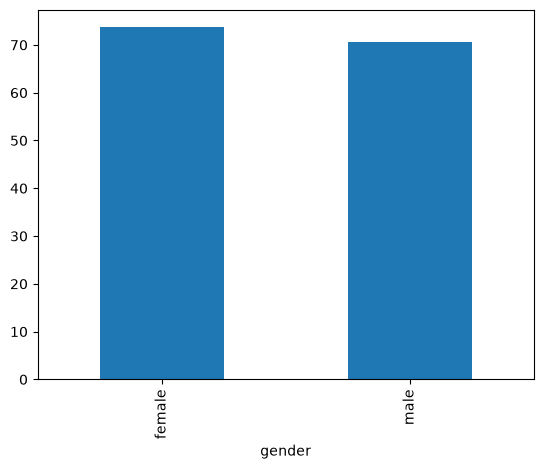

In [18]:
### 📊 Chart 1 — Bar Chart: Average Score by Gender
ans1 = df.groupby('gender')['average_score'].mean()
ans1.plot(kind = 'bar')

### Insights:
- All three subjects (math, reading, and writing) show a roughly normal distribution of scores, with most students scoring in the middle range.
- There aren't significant signs of bimodal distributions or extreme skews, suggesting a relatively balanced performance across the student population for these subjects.

### Insights:
- Females generally have higher average scores in reading and writing, while males have slightly higher average scores in math.
- The difference in scores between genders seems to be more pronounced in reading and writing compared to math.

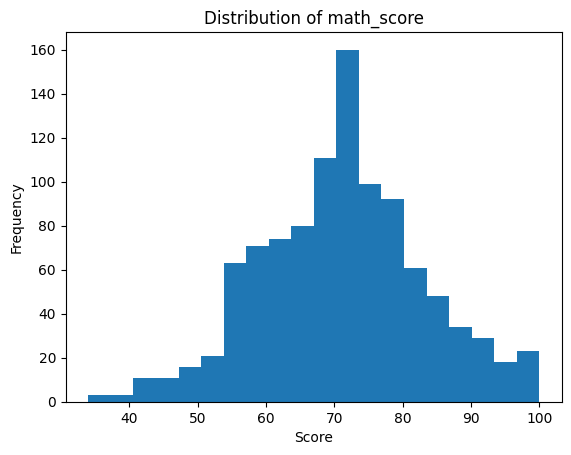

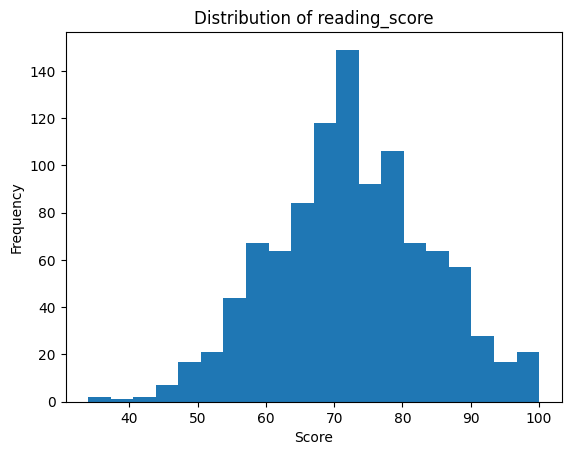

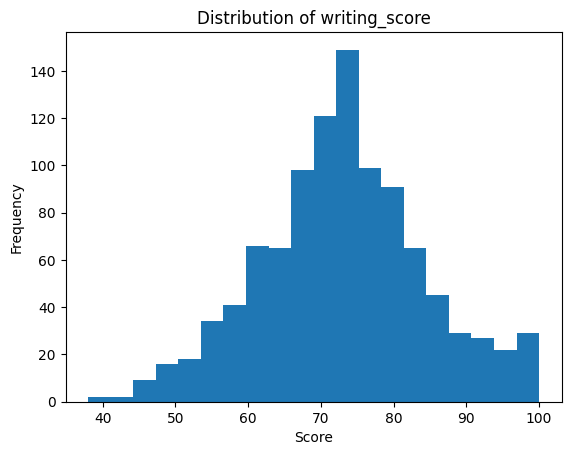

In [ ]:
### 📉 Chart 2 — Histogram: Score Distribution
subject = ['math_score','reading_score','writing_score']
for col in subject:
  plt.hist(df[col], bins = 20)
  plt.title(f'Distribution of {col}')
  plt.xlabel('Score')
  plt.ylabel('Frequency')
  plt.show()

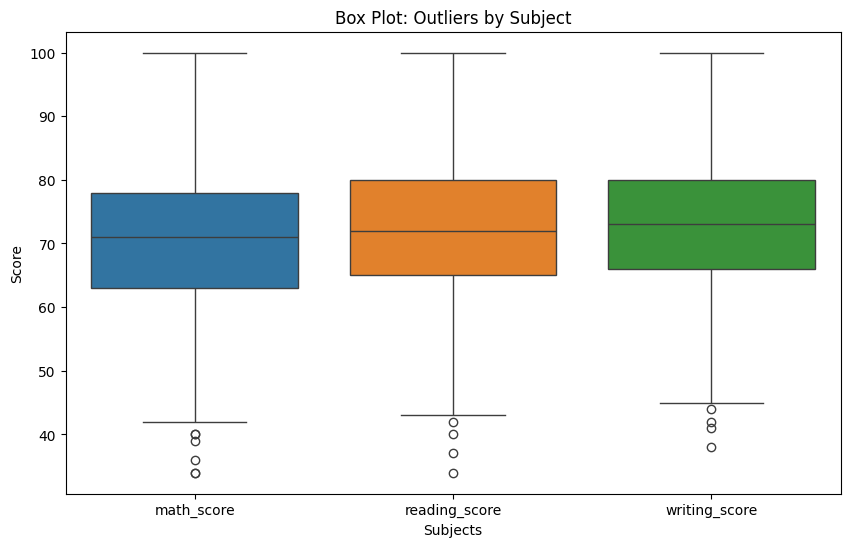

In [ ]:
### 📦 Chart 3 — Box Plot: Outliers by Subject
import matplotlib.pyplot as plt
import seaborn as sns

# Subject scores
subjects = ['math_score', 'reading_score', 'writing_score']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[subjects])

plt.title('Box Plot: Outliers by Subject')
plt.xlabel('Subjects')
plt.ylabel('Score')

plt.show()





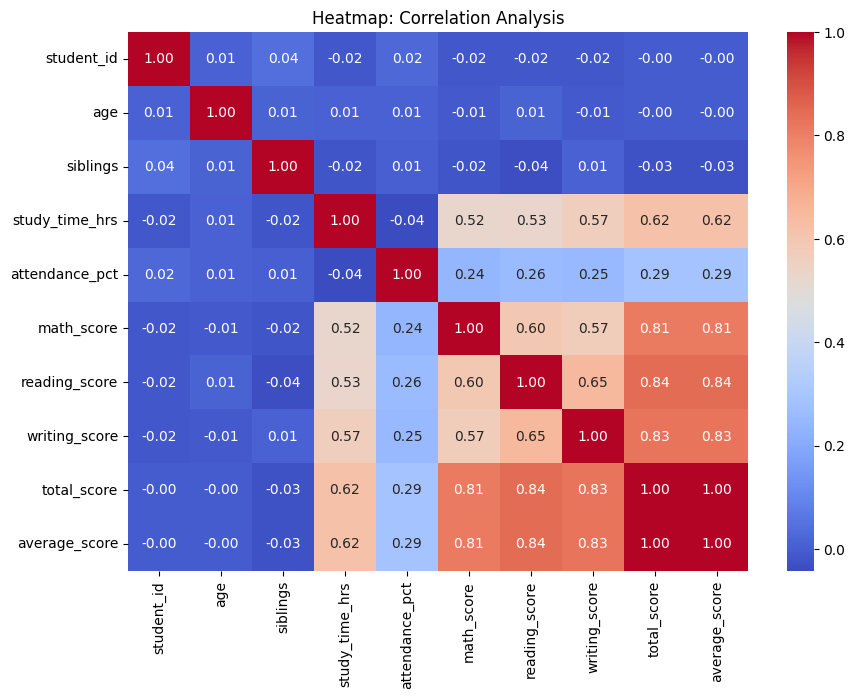

In [ ]:
### 🔥 Chart 4 — Heatmap: Correlation Analysis

plt.figure(figsize=(10, 7))

# Numeric columns
numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap: Correlation Analysis')
plt.show()

In [ ]:
### 📈 Chart 5 — Study Time vs Average Score
print(df.columns.tolist())

['student_id', 'age', 'gender', 'parent_education', 'lunch', 'internet_access', 'extracurricular', 'siblings', 'test_prep_course', 'study_time_hrs', 'attendance_pct', 'math_score', 'reading_score', 'writing_score', 'total_score', 'average_score', 'grade', 'pass_fail']


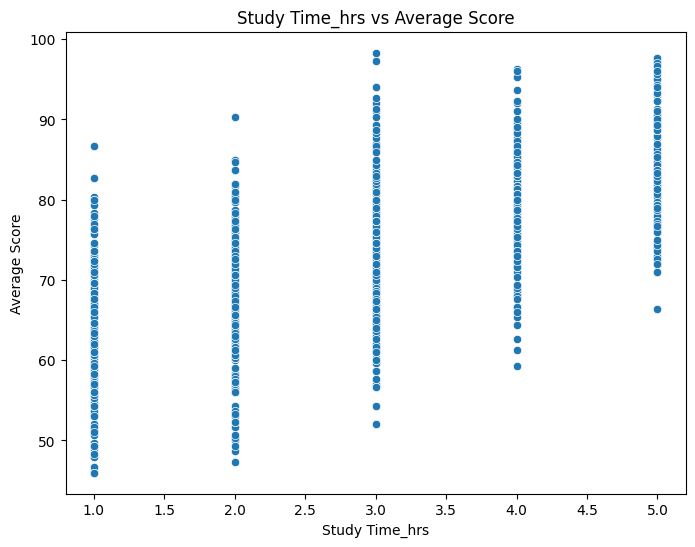

In [ ]:
df['average_score'] = (
    df['math_score'] +
    df['reading_score'] +
    df['writing_score']
) / 3

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='study_time_hrs',
    y='average_score'
)

plt.title('Study Time_hrs vs Average Score')
plt.xlabel('Study Time_hrs')
plt.ylabel('Average Score')

plt.show()